지금까지 학습한 모든 모델에 대해 세 가지 표준적인 representation 분석을 돌린다.

1. **Linear probing accuracy** -- backbone freeze, penultimate feature 위에 linear classifier
2. **PCA eigenspectrum** (Stringer et al. 방식) -- log-log 스펙트럼 기울기
3. **Manifold capacity** (Chung/Sompolinsky/DiCarlo 방식, `mftma` 패키지)


In [6]:
import os
import sys
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Dataset, Subset

sys.path.append('..')
from src.data.degredation import get_transforms
from src.models.resnet import resnet18

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
SAVE_FIGURES = False  # True로 바꾸면 figures/에 svg 저장 -- 기본은 화면 표시만, 디스크 절약


cuda


In [7]:
# 모델 불러오기 

save_dir = os.path.join("..", "results", "cifar10-0913")
num_net = 3

model_tags = [
    "wo", "r", "g", "l5_0.001", "l5_0.01", "rg",
    "rl_g10l5_0.001", "gl_g10l5_0.001",
    "rgl_g10l5_0.001", "rgl_g10l5_0.005", "rgl_g10l5_0.01",
    "rgl_g10l10_0.001", "rgl_g10l10_0.005", "rgl_g10l10_0.01",
    "rgl_g5l5_0.001", "rgl_g5l5_0.01",
]

def ckpt_path(tag, net_idx):
    return os.path.join(save_dir, f"best_model_{tag}_{net_idx}.pth")

def load_model(tag, net_idx):
    model = resnet18().to(device)
    model.load_state_dict(torch.load(ckpt_path(tag, net_idx), map_location=device))
    model.eval()
    return model

available_tags = [t for t in model_tags if all(os.path.exists(ckpt_path(t, i)) for i in range(num_net))]
missing_tags = [t for t in model_tags if t not in available_tags]
print(f"available: {available_tags}")
if missing_tags:
    print(f"missing : {missing_tags}")

available: ['wo', 'r', 'g', 'l5_0.001', 'l5_0.01', 'rg', 'rl_g10l5_0.001', 'gl_g10l5_0.001', 'rgl_g10l5_0.001', 'rgl_g10l5_0.005', 'rgl_g10l5_0.01', 'rgl_g10l10_0.001', 'rgl_g10l10_0.005', 'rgl_g10l10_0.01', 'rgl_g5l5_0.001', 'rgl_g5l5_0.01']


In [8]:
dataset_dir = '../dataset'

cifar_train = torchvision.datasets.CIFAR10(
    root=dataset_dir, train=True, download=True,
    transform=get_transforms("cifar10", blur=0, color=1, test=True),
)
cifar_test = torchvision.datasets.CIFAR10(
    root=dataset_dir, train=False, download=True,
    transform=get_transforms("cifar10", blur=0, color=1, test=True),
)
print(f"train={len(cifar_train)}, test={len(cifar_test)}")

train=50000, test=10000


In [9]:
@torch.no_grad()
def extract_features(model, dataset, indices=None, batch_size=256):
    """resnet18의 avg_pool 출력(512차원, penultimate layer)을 representation으로 사용"""
    ds = Subset(dataset, indices) if indices is not None else dataset
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)

    feats_out, labels_out = [], []

    def hook_fn(module, inp, out):
        feats_out.append(torch.flatten(out, 1).cpu().numpy())

    handle = model.avg_pool.register_forward_hook(hook_fn)
    for inputs, labels in loader:
        model(inputs.to(device))
        labels_out.append(labels.numpy())
    handle.remove()

    return np.concatenate(feats_out), np.concatenate(labels_out)

#### 1. Linear probing accuracy

- 학습 끝난 모델 weight freeze 해두고 내부 feature만 뽑아서 - 거기에 hidden state 없이 logistic regression만 얹기. 
- cifar train 5000장으로 학습시키고 test set으로 정확도를 잰다 
- 클래스별 직선 1개로 나뉠 만큼 깔끔하게 정리되어 있는가? 

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

rng = np.random.RandomState(0)
probe_train_idx = rng.choice(len(cifar_train), 5000, replace=False)

probe_results = {}
for tag in available_tags:
    accs = []
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        train_feats, train_labels = extract_features(model, cifar_train, probe_train_idx)
        test_feats, test_labels = extract_features(model, cifar_test)

        scaler = StandardScaler().fit(train_feats)
        clf = LogisticRegression(max_iter=2000, C=1.0)
        clf.fit(scaler.transform(train_feats), train_labels)
        acc = clf.score(scaler.transform(test_feats), test_labels)
        accs.append(acc)
    probe_results[tag] = accs
    print(f"{tag:16s}: probe acc {np.mean(accs)*100:.2f} (+/- {np.std(accs)*100:.2f})")

wo              : probe acc 90.06 (+/- 0.08)
r               : probe acc 89.79 (+/- 0.84)
g               : probe acc 90.11 (+/- 0.22)
l5_0.001        : probe acc 91.11 (+/- 0.20)
l5_0.01         : probe acc 83.65 (+/- 1.09)
rg              : probe acc 89.81 (+/- 0.25)
rl_g10l5_0.001  : probe acc 89.66 (+/- 0.08)
gl_g10l5_0.001  : probe acc 89.41 (+/- 0.20)
rgl_g10l5_0.001 : probe acc 87.75 (+/- 0.13)
rgl_g10l5_0.005 : probe acc 81.58 (+/- 2.99)
rgl_g10l5_0.01  : probe acc 74.02 (+/- 0.20)
rgl_g10l10_0.001: probe acc 88.36 (+/- 0.22)
rgl_g10l10_0.005: probe acc 82.54 (+/- 0.70)
rgl_g10l10_0.01 : probe acc 79.12 (+/- 0.91)
rgl_g5l5_0.001  : probe acc 88.00 (+/- 0.49)
rgl_g5l5_0.01   : probe acc 74.95 (+/- 1.14)


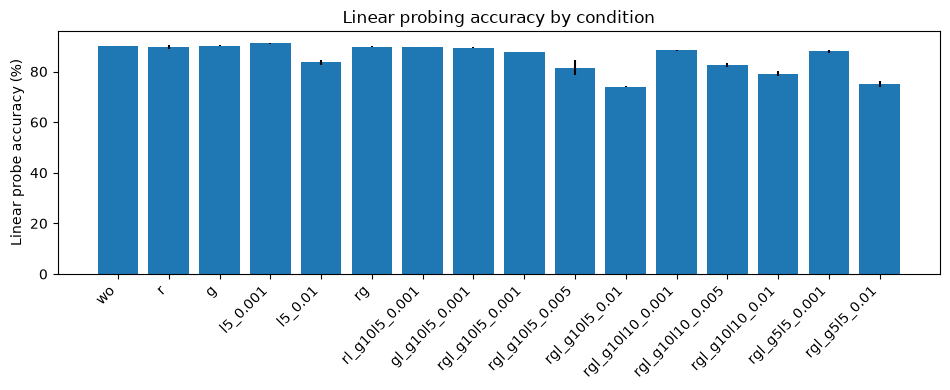

In [11]:
tags = list(probe_results.keys())
means = [np.mean(probe_results[t]) * 100 for t in tags]
stds = [np.std(probe_results[t]) * 100 for t in tags]

plt.figure(figsize=(max(6, len(tags) * 0.6), 4))
plt.bar(range(len(tags)), means, yerr=stds)
plt.xticks(range(len(tags)), tags, rotation=45, ha='right')
plt.ylabel("Linear probe accuracy (%)")
plt.title("Linear probing accuracy by condition")
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig("../figures/representation_linear_probe.svg")

얻은 결과 : 100배 억제 < 20배 억제 < 10배 억제 가 더 잘 분리한다. 그러나 baseline이 거의 제일 잘 선형적으로 분리된다 

#### 1b. Few-shot linear probe generalization (저데이터 일반화)

전체 데이터(5000장) probe 대신 class당 k=5/10/20장만 써서 linear probe를 다시 학습.
capacity가 낮은 조건(예: `rgl_L10_0.01`)이 전체 데이터에서는 `r`/`rg`보다 probe acc가 낮더라도,
저데이터 상황에서는 오히려 역전되는지 확인 -- 압축된 표상일수록 적은 샘플로도 더 잘 일반화한다는
가설(Fang & Sims 2025, Orhan & Lake 2024)과 연결됨. capacity가 높으면 다 좋다는 통념과 충돌한다는
점에서 역전이 관찰되면 흥미로운 결과.

클래스 불균형 없이 class당 균등하게 샘플링하고, k가 작을수록 샘플링 노이즈가 크므로 서로 다른 시드로
5번 반복해 평균.

In [12]:
few_shot_ks = [5, 10, 20]
n_repeats = 5

train_targets = np.array(cifar_train.targets)


def stratified_few_shot_indices(targets, k, num_classes=10, seed=0):
    rng_fs = np.random.RandomState(seed)
    idx = []
    for c in range(num_classes):
        class_idx = np.where(targets == c)[0]
        idx.append(rng_fs.choice(class_idx, k, replace=False))
    return np.concatenate(idx)


fewshot_probe_results = {k: {} for k in few_shot_ks}

for tag in available_tags:
    per_k_accs = {k: [] for k in few_shot_ks}
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        test_feats, test_labels = extract_features(model, cifar_test)
        for k in few_shot_ks:
            repeat_accs = []
            for seed in range(n_repeats):
                idx = stratified_few_shot_indices(train_targets, k, seed=seed)
                train_feats, train_labels = extract_features(model, cifar_train, idx)
                scaler = StandardScaler().fit(train_feats)
                clf = LogisticRegression(max_iter=2000, C=1.0)
                clf.fit(scaler.transform(train_feats), train_labels)
                repeat_accs.append(clf.score(scaler.transform(test_feats), test_labels))
            per_k_accs[k].append(np.mean(repeat_accs))  # 이 net에 대해 시드 반복 평균
    for k in few_shot_ks:
        fewshot_probe_results[k][tag] = per_k_accs[k]
    print(f"{tag:16s}: " + "  ".join(f"k={k}:{np.mean(per_k_accs[k])*100:.2f}" for k in few_shot_ks))

wo              : k=5:87.57  k=10:88.71  k=20:89.24
r               : k=5:88.69  k=10:89.22  k=20:89.40
g               : k=5:86.85  k=10:88.08  k=20:88.84
l5_0.001        : k=5:88.84  k=10:89.81  k=20:90.33
l5_0.01         : k=5:74.55  k=10:79.14  k=20:81.25
rg              : k=5:88.73  k=10:89.14  k=20:89.43
rl_g10l5_0.001  : k=5:87.42  k=10:88.47  k=20:88.78
gl_g10l5_0.001  : k=5:86.06  k=10:87.52  k=20:88.17
rgl_g10l5_0.001 : k=5:84.67  k=10:85.93  k=20:86.49
rgl_g10l5_0.005 : k=5:75.80  k=10:78.74  k=20:80.09
rgl_g10l5_0.01  : k=5:66.64  k=10:70.62  k=20:72.85
rgl_g10l10_0.001: k=5:85.53  k=10:86.71  k=20:87.38
rgl_g10l10_0.005: k=5:77.08  k=10:79.65  k=20:81.02
rgl_g10l10_0.01 : k=5:71.02  k=10:74.89  k=20:77.27
rgl_g5l5_0.001  : k=5:85.38  k=10:86.46  k=20:87.05
rgl_g5l5_0.01   : k=5:67.49  k=10:71.16  k=20:73.49



=== data regime별 순위 (역전 여부 확인) ===
5           : rg(88.7) > r(88.7) > rgl_g10l10_0.01(71.0)
10          : r(89.2) > rg(89.1) > rgl_g10l10_0.01(74.9)
20          : rg(89.4) > r(89.4) > rgl_g10l10_0.01(77.3)
full        : rg(89.8) > r(89.8) > rgl_g10l10_0.01(79.1)


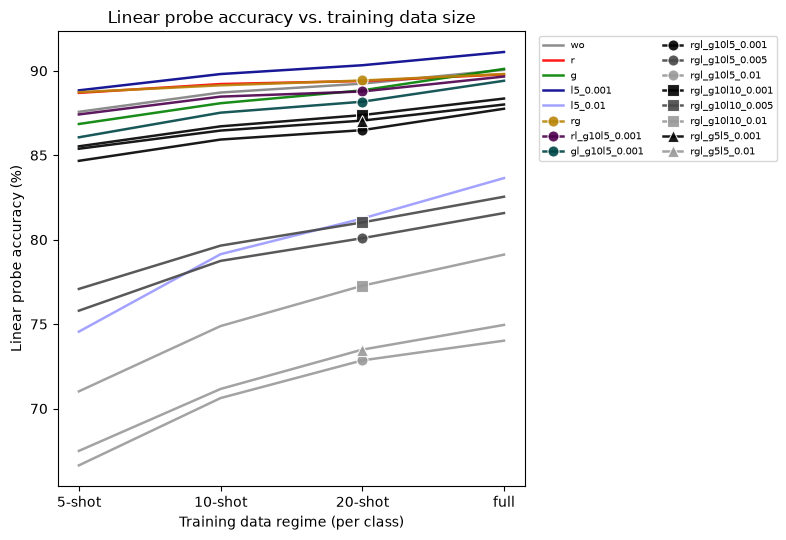

In [13]:
import matplotlib.colors as mcolors
BASE_COLOR = {
    frozenset(): "gray",                        # wo
    frozenset({"r"}): "red",
    frozenset({"g"}): "green",
    frozenset({"l"}): "blue",
    frozenset({"r", "g"}): "darkgoldenrod",      # rg = r+g
    frozenset({"g", "l"}): "teal",               # gl = g+l
    frozenset({"r", "l"}): "darkmagenta",        # rl = r+l
    frozenset({"r", "g", "l"}): "black",         # rgl
}
SCHEDULE_MARKER = {"rg": "o", "l5": "o", "g10l5": "o", "g10l10": "s", "g5l5": "^"}

def parse_tag_style(tag):
    """tag -> (mechanism_set, shade_level('dark'/'mid'/'light'/None), schedule_key)"""
    if tag == "wo":
        return frozenset(), None, None
    if tag == "r":
        return frozenset({"r"}), None, None
    if tag == "g":
        return frozenset({"g"}), None, None
    if tag == "rg":
        return frozenset({"r", "g"}), None, "rg"

    parts = tag.split("_")
    lr = parts[-1]  # '0.001' / '0.01' / '0.005'
    shade = {"0.001": "dark", "0.01": "light", "0.005": "mid"}[lr]
    if tag.startswith("l5_"):
        return frozenset({"l"}), shade, None
    if tag.startswith("rl_"):
        return frozenset({"r", "l"}), shade, parts[1]
    if tag.startswith("gl_"):
        return frozenset({"g", "l"}), shade, parts[1]
    if tag.startswith("rgl_"):
        return frozenset({"r", "g", "l"}), shade, parts[1]
    return frozenset(), None, None


def shade_color(base_name, level):
    r, g, b = mcolors.to_rgb(base_name)
    if level == "dark":
        return (r * 0.55, g * 0.55, b * 0.55)
    if level == "light":
        return (r + (1 - r) * 0.6, g + (1 - g) * 0.6, b + (1 - b) * 0.6)
    if level == "mid":
        return (r + (1 - r) * 0.28, g + (1 - g) * 0.28, b + (1 - b) * 0.28)
    return (r, g, b)


def tag_style(tag):
    mech, shade, schedule = parse_tag_style(tag)
    color = shade_color(BASE_COLOR[mech], shade) if shade else mcolors.to_rgb(BASE_COLOR[mech])
    marker = SCHEDULE_MARKER.get(schedule)
    return color, marker


regimes = few_shot_ks + ["full(5000)"]
mid_idx = len(regimes) // 2  

plt.figure(figsize=(8, 5.5))
for tag in available_tags:
    means = [np.mean(fewshot_probe_results[k][tag]) * 100 for k in few_shot_ks] + [np.mean(probe_results[tag]) * 100]
    color, marker = tag_style(tag)
    plt.plot(range(len(regimes)), means, color=color, marker=marker, markevery=[mid_idx],
              markersize=8, markerfacecolor=color, markeredgecolor="white", markeredgewidth=0.8,
              label=tag, alpha=0.9, linewidth=1.8)
plt.xticks(range(len(regimes)), [f"{k}-shot" for k in few_shot_ks] + ["full"])
plt.xlabel("Training data regime (per class)")
plt.ylabel("Linear probe accuracy (%)")
plt.title("Linear probe accuracy vs. training data size")
plt.legend(fontsize=7, ncol=2, bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig("../figures/representation_fewshot_linear_probe.svg")
compare_tags = [t for t in ("r", "rg", "rgl_g10l10_0.01") if t in available_tags]
if len(compare_tags) >= 2:
    print("\n=== data regime별 순위 (역전 여부 확인) ===")
    for k in few_shot_ks + ["full"]:
        if k == "full":
            accs = {t: np.mean(probe_results[t]) * 100 for t in compare_tags}
        else:
            accs = {t: np.mean(fewshot_probe_results[k][t]) * 100 for t in compare_tags}
        ranked = sorted(accs.items(), key=lambda kv: -kv[1])
        print(f"{str(k):12s}: " + " > ".join(f"{t}({v:.1f})" for t, v in ranked))

2. PCA eigenspectrum (Stringer et al. 방식)

표현 벡터들의 공분산 고유값을 rank 순으로 정렬해서 log-log에 그리고, 기울기를 구함.
관례대로 처음 몇 개(가장 큰 분산, 덜 대표적)와 꼬리(노이즈)를 빼고 중간 구간에서 직선을 피팅.

wo              : slope=-1.313±0.006  R^2=0.996±0.000
r               : slope=-1.622±0.015  R^2=0.997±0.001
g               : slope=-1.350±0.027  R^2=0.992±0.001
l5_0.001        : slope=-1.475±0.036  R^2=0.997±0.001
l5_0.01         : slope=-1.634±0.010  R^2=0.996±0.000
rg              : slope=-1.594±0.024  R^2=0.997±0.001
rl_g10l5_0.001  : slope=-1.691±0.018  R^2=0.998±0.000
gl_g10l5_0.001  : slope=-1.455±0.049  R^2=0.996±0.000
rgl_g10l5_0.001 : slope=-1.628±0.019  R^2=0.997±0.000
rgl_g10l5_0.005 : slope=-1.573±0.034  R^2=0.996±0.001
rgl_g10l5_0.01  : slope=-1.655±0.043  R^2=0.985±0.003
rgl_g10l10_0.001: slope=-1.609±0.027  R^2=0.997±0.001
rgl_g10l10_0.005: slope=-1.500±0.008  R^2=0.996±0.001
rgl_g10l10_0.01 : slope=-1.636±0.046  R^2=0.963±0.011
rgl_g5l5_0.001  : slope=-1.593±0.027  R^2=0.998±0.000
rgl_g5l5_0.01   : slope=-1.735±0.089  R^2=0.971±0.011


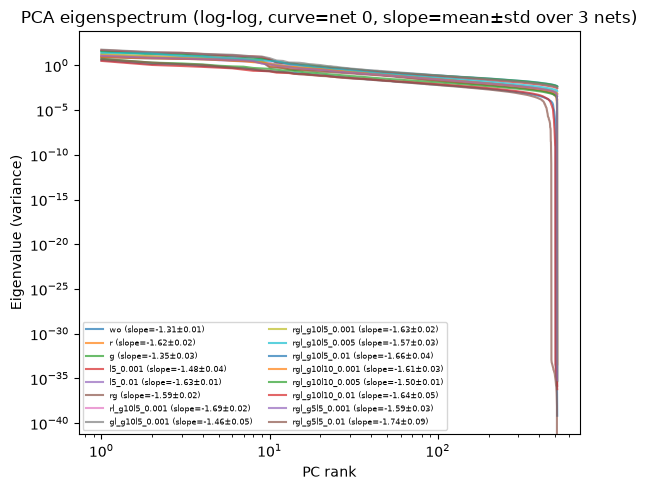

In [14]:
from scipy.stats import linregress

rng = np.random.RandomState(1)
pca_idx = rng.choice(len(cifar_test), 2000, replace=False)


def eigenspectrum_slope(feats, skip_head=10, tail_frac=0.8):
    feats = feats - feats.mean(axis=0, keepdims=True)
    # 샘플 수 < 특징 차원이라 covariance 대신 SVD로 바로 고유값 계산
    s = np.linalg.svd(feats, compute_uv=False)
    eigvals = (s ** 2) / (feats.shape[0] - 1)
    ranks = np.arange(1, len(eigvals) + 1)

    fit_end = int(len(eigvals) * tail_frac)
    log_rank = np.log10(ranks[skip_head:fit_end])
    log_eig = np.log10(eigvals[skip_head:fit_end])
    slope, intercept, r, _, _ = linregress(log_rank, log_eig)
    return eigvals, slope, r


pca_results = {}
plt.figure(figsize=(6, 5))
for tag in available_tags:
    slopes, r2s = [], []
    eigvals_net0 = None
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        feats, _ = extract_features(model, cifar_test, pca_idx)
        eigvals, slope, r = eigenspectrum_slope(feats)
        slopes.append(slope)
        r2s.append(r ** 2)
        if net_idx == 0:
            eigvals_net0 = eigvals
    slope_mean, slope_std = np.mean(slopes), np.std(slopes)
    r2_mean, r2_std = np.mean(r2s), np.std(r2s)
    pca_results[tag] = dict(slope_mean=slope_mean, slope_std=slope_std, r2_mean=r2_mean, r2_std=r2_std)
    plt.plot(np.arange(1, len(eigvals_net0) + 1), eigvals_net0,
              label=f"{tag} (slope={slope_mean:.2f}±{slope_std:.2f})", alpha=0.7)
    print(f"{tag:16s}: slope={slope_mean:.3f}±{slope_std:.3f}  R^2={r2_mean:.3f}±{r2_std:.3f}")

plt.xscale("log")
plt.yscale("log")
plt.xlabel("PC rank")
plt.ylabel("Eigenvalue (variance)")
plt.title("PCA eigenspectrum (log-log, curve=net 0, slope=mean±std over 3 nets)")
plt.legend(fontsize=6, ncol=2)
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig("../figures/representation_pca_eigenspectrum.svg")

3. Manifold capacity (Chung/Sompolinsky/DiCarlo 방식)

CIFAR-10 클래스 하나 = manifold 하나로 취급 (같은 클래스 내 서로 다른 이미지들 = 그 물체 정체성의 변형들)

10개 클래스라 관례적 최소 권장(20~30개)보다 적지만, CIFAR-10 세팅에서 이 분석을 할 때 흔히 쓰는 방식이 이거라 그대로 감

manifold당 50장 샘플

In [15]:
#!pip install cvxopt autograd "pymanopt==0.2.5"
#!pip install git+https://github.com/schung039/neural_manifolds_replicaMFT.git

In [16]:
num_manifolds = 10   # CIFAR-10 클래스 수
samples_per_manifold = 50

rng = np.random.RandomState(2)
targets = np.array(cifar_test.targets)
manifold_idx_by_class = {
    c: rng.choice(np.where(targets == c)[0], samples_per_manifold, replace=False)
    for c in range(num_manifolds)
}


def extract_manifold_features(model):
    """mftma가 기대하는 형식: 클래스(manifold)별 (feature_dim, n_samples) 배열의 리스트."""
    XtotT = []
    for c in range(num_manifolds):
        feats, _ = extract_features(model, cifar_test, manifold_idx_by_class[c])
        XtotT.append(feats.T)  # (feature_dim, samples_per_manifold)
    return XtotT

In [17]:
from mftma.manifold_analysis_correlation import manifold_analysis_corr as manifold_analysis_correlation

kappa = 0
n_t = 200  # 논문/패키지 데모 기본값 -- 정확도 필요하면 늘리기(느려짐)

manifold_results = {}
for tag in available_tags:
    capacities, radii, dims = [], [], []
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        XtotT = extract_manifold_features(model)
        a, r, d, r0, K = manifold_analysis_correlation(XtotT, kappa, n_t)
        capacities.append(1 / np.mean(1 / a))
        radii.append(np.mean(r))
        dims.append(np.mean(d))
    manifold_results[tag] = dict(
        capacity_mean=np.mean(capacities), capacity_std=np.std(capacities),
        radius_mean=np.mean(radii), radius_std=np.std(radii),
        dimension_mean=np.mean(dims), dimension_std=np.std(dims),
    )
    print(f"{tag:16s}: capacity={np.mean(capacities):.4f}±{np.std(capacities):.4f}  "
          f"radius={np.mean(radii):.4f}±{np.std(radii):.4f}  dimension={np.mean(dims):.2f}±{np.std(dims):.2f}")

wo              : capacity=0.2443±0.0123  radius=0.7956±0.0055  dimension=9.20±0.26
r               : capacity=0.3094±0.0068  radius=0.7683±0.0005  dimension=7.29±0.28
g               : capacity=0.2271±0.0042  radius=0.8177±0.0114  dimension=9.73±0.18
l5_0.001        : capacity=0.2883±0.0068  radius=0.7919±0.0278  dimension=7.59±0.17
l5_0.01         : capacity=0.1743±0.0238  radius=0.9757±0.0298  dimension=11.12±1.15
rg              : capacity=0.2962±0.0046  radius=0.7793±0.0056  dimension=7.47±0.05
rl_g10l5_0.001  : capacity=0.2965±0.0110  radius=0.7789±0.0088  dimension=7.39±0.23
gl_g10l5_0.001  : capacity=0.2370±0.0218  radius=0.8408±0.0290  dimension=8.94±0.62
rgl_g10l5_0.001 : capacity=0.2555±0.0044  radius=0.8197±0.0106  dimension=8.55±0.05
rgl_g10l5_0.005 : capacity=0.1947±0.0183  radius=0.9230±0.0256  dimension=10.36±0.89
rgl_g10l5_0.01  : capacity=0.1413±0.0130  radius=1.0015±0.0161  dimension=13.09±0.39
rgl_g10l10_0.001: capacity=0.2520±0.0067  radius=0.8320±0.0046  dimension

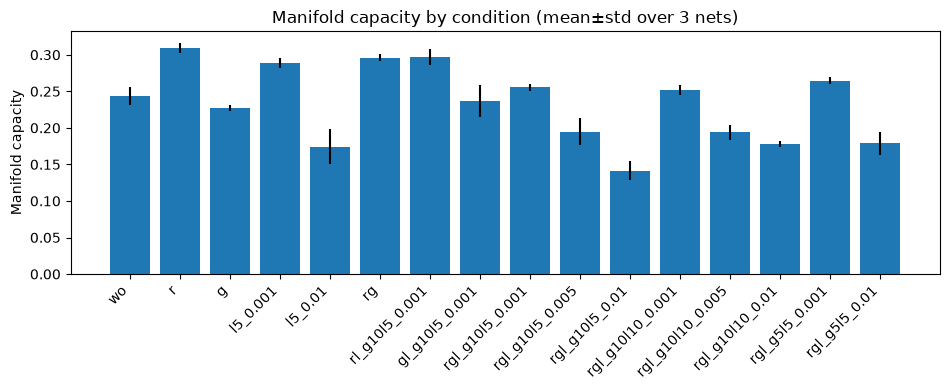

In [18]:
tags = list(manifold_results.keys())
caps = [manifold_results[t]["capacity_mean"] for t in tags]
caps_std = [manifold_results[t]["capacity_std"] for t in tags]

plt.figure(figsize=(max(6, len(tags) * 0.6), 4))
plt.bar(range(len(tags)), caps, yerr=caps_std)
plt.xticks(range(len(tags)), tags, rotation=45, ha='right')
plt.ylabel("Manifold capacity")
plt.title("Manifold capacity by condition (mean±std over 3 nets)")
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig("../figures/representation_manifold_capacity.svg")

#### 3b. Calinski-Harabasz separability index (CH)

진짜 클래스 라벨(10개)을 "클러스터"로 놓고, 클래스 간 분리도(between-class scatter) 대 클래스 내 조밀도(within-class scatter)의 비율을 봄 -- ANOVA의 F-statistic과 같은 발상.

```
CH = [Tr(B)/(k-1)] / [Tr(W)/(n-k)]
```

manifold capacity와 비슷하게 "표현이 클래스별로 잘 갈라져 있나"를 재지만, 유클리드 centroid 기반이라 훨씬 단순하고 빠름(sklearn 내장). PCA 셀에서 이미 뽑아둔 `pca_idx`(test 2000장) 재사용.

In [39]:
from sklearn.metrics import calinski_harabasz_score

ch_results = {}
for tag in available_tags:
    scores = []
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        feats, labels = extract_features(model, cifar_test, pca_idx)
        scores.append(calinski_harabasz_score(feats, labels))
    ch_results[tag] = scores
    print(f"{tag:16s}: CH index = {np.mean(scores):.1f} ± {np.std(scores):.1f}")

wo              : CH index = 234.8 ± 4.0
r               : CH index = 274.3 ± 16.4
g               : CH index = 201.5 ± 10.2
l5_0.001        : CH index = 273.3 ± 25.6
l5_0.01         : CH index = 130.2 ± 17.1
rg              : CH index = 276.1 ± 6.3
rl_g10l5_0.001  : CH index = 266.6 ± 13.3
gl_g10l5_0.001  : CH index = 232.8 ± 33.4
rgl_g10l5_0.001 : CH index = 234.9 ± 7.0
rgl_g10l5_0.005 : CH index = 171.3 ± 15.8
rgl_g10l5_0.01  : CH index = 159.3 ± 12.1
rgl_g10l10_0.001: CH index = 211.6 ± 8.5
rgl_g10l10_0.005: CH index = 171.8 ± 2.0
rgl_g10l10_0.01 : CH index = 165.0 ± 13.6
rgl_g5l5_0.001  : CH index = 226.8 ± 5.1
rgl_g5l5_0.01   : CH index = 183.3 ± 12.0


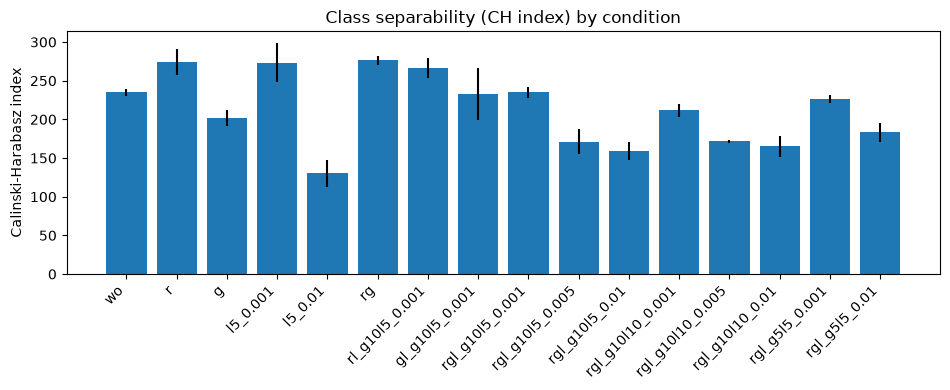

In [ ]:
tags = [t for t in ch_results if not (t.endswith("_0.01") or t.endswith("_0.005"))]  # alpha=0.001인 것만 (+ alpha 없는 wo/r/g/rg)
means = [np.mean(ch_results[t]) for t in tags]

cmap = plt.get_cmap("Blues")
bar_colors = [cmap(0.3 + 0.22 * len(parse_tag_style(t)[0])) for t in tags]  # factor 개수(mechanism 수)가 많을수록 진하게
dot_offsets = [-0.12, 0.0, 0.12]  # num_net=3개 점을 겹치지 않게 살짝 벌려서 표시

plt.figure(figsize=(max(6, len(tags) * 0.6), 4))
plt.bar(range(len(tags)), means, color=bar_colors, zorder=2)
for xi, t in enumerate(tags):
    scores = np.array(ch_results[t])
    for off, s in zip(dot_offsets, scores):
        plt.scatter(xi + off, s, color="gray", s=25, zorder=3)
for xi, m in enumerate(means):
    plt.text(xi, m + 5, f"{m:.1f}", ha="center", fontsize=8)

plt.xticks(range(len(tags)), tags, rotation=45, ha="right")
plt.ylabel("CH index")
plt.title("Class separability by CH")
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig("../figures/representation_ch_index.svg")
plt.show()

4. 표현 강건성 (clean vs perturbed)

같은 이미지를 원본 그대로 넣었을 때와 perturbation(가우시안 노이즈 / 회전 / 실제 CIFAR-10-C corruption)을
가해서 넣었을 때의 representation을 각각 뽑아서 linear CKA로 얼마나 비슷한지 하나의 점수로 봄.
점수가 1에 가까울수록 그 perturbation에 표현이 안 흔들린다는 뜻(강건함).

corruption은 이미 다운로드된 CIFAR-10-C(`motion_blur`, severity 5)를 재사용 -- 인덱스가 원본 test set과
1:1 대응되므로 같은 이미지의 왜곡 버전으로 바로 쓸 수 있음.

In [19]:
from PIL import Image
from torchvision import transforms as T
import torchvision.transforms.functional as TF

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD = (0.2023, 0.1994, 0.2010)
_normalize = T.Normalize(CIFAR_MEAN, CIFAR_STD)

cifar_test_raw = torchvision.datasets.CIFAR10(root=dataset_dir, train=False, download=True)  # transform 없음, PIL 그대로

cifar10c_root = os.path.join(dataset_dir, "CIFAR-10-C")
motion_blur_sev5 = np.load(os.path.join(cifar10c_root, "motion_blur.npy"))[40000:50000]  # severity 5, index가 cifar_test_raw와 1:1 대응


def build_batch(indices, perturb):
    imgs = []
    for idx in indices:
        if perturb == "corrupt":
            img = Image.fromarray(motion_blur_sev5[idx])
        else:
            img, _ = cifar_test_raw[idx]
        x = TF.to_tensor(img)
        if perturb == "noise":
            x = torch.clamp(x + torch.randn_like(x) * 0.1, 0, 1)
        elif perturb == "rotate":
            x = TF.rotate(x, 30)
        imgs.append(_normalize(x))
    return torch.stack(imgs).to(device)


@torch.no_grad()
def extract_features_batch(model, batch):
    feats_out = []

    def hook_fn(module, inp, out):
        feats_out.append(torch.flatten(out, 1).cpu().numpy())

    handle = model.avg_pool.register_forward_hook(hook_fn)
    model(batch)
    handle.remove()
    return np.concatenate(feats_out)


def linear_cka(X, Y):
    X = X - X.mean(axis=0, keepdims=True)
    Y = Y - Y.mean(axis=0, keepdims=True)
    hsic = np.linalg.norm(X.T @ Y, ord='fro') ** 2
    norm_x = np.linalg.norm(X.T @ X, ord='fro')
    norm_y = np.linalg.norm(Y.T @ Y, ord='fro')
    return hsic / (norm_x * norm_y)

In [20]:
rng = np.random.RandomState(3)
robust_idx = rng.choice(len(cifar_test_raw), 1000, replace=False)
perturbations = ["noise", "rotate", "corrupt"]

clean_batch = build_batch(robust_idx, "clean")
perturbed_batches = {p: build_batch(robust_idx, p) for p in perturbations}

robustness_results = {}
for tag in available_tags:
    per_perturb = {p: [] for p in perturbations}
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        clean_feats = extract_features_batch(model, clean_batch)
        for p in perturbations:
            pert_feats = extract_features_batch(model, perturbed_batches[p])
            per_perturb[p].append(linear_cka(clean_feats, pert_feats))
    robustness_results[tag] = per_perturb
    print(f"{tag:16s}: " + "  ".join(f"{p}={np.mean(per_perturb[p]):.3f}" for p in perturbations))

wo              : noise=0.564  rotate=0.543  corrupt=0.717
r               : noise=0.452  rotate=0.434  corrupt=0.628
g               : noise=0.642  rotate=0.558  corrupt=0.720
l5_0.001        : noise=0.536  rotate=0.439  corrupt=0.667
l5_0.01         : noise=0.528  rotate=0.377  corrupt=0.521
rg              : noise=0.503  rotate=0.456  corrupt=0.643
rl_g10l5_0.001  : noise=0.407  rotate=0.409  corrupt=0.621
gl_g10l5_0.001  : noise=0.745  rotate=0.522  corrupt=0.687
rgl_g10l5_0.001 : noise=0.689  rotate=0.511  corrupt=0.677
rgl_g10l5_0.005 : noise=0.794  rotate=0.466  corrupt=0.692
rgl_g10l5_0.01  : noise=0.856  rotate=0.575  corrupt=0.777
rgl_g10l10_0.001: noise=0.722  rotate=0.494  corrupt=0.669
rgl_g10l10_0.005: noise=0.842  rotate=0.496  corrupt=0.762
rgl_g10l10_0.01 : noise=0.866  rotate=0.492  corrupt=0.750
rgl_g5l5_0.001  : noise=0.663  rotate=0.504  corrupt=0.667
rgl_g5l5_0.01   : noise=0.846  rotate=0.520  corrupt=0.762


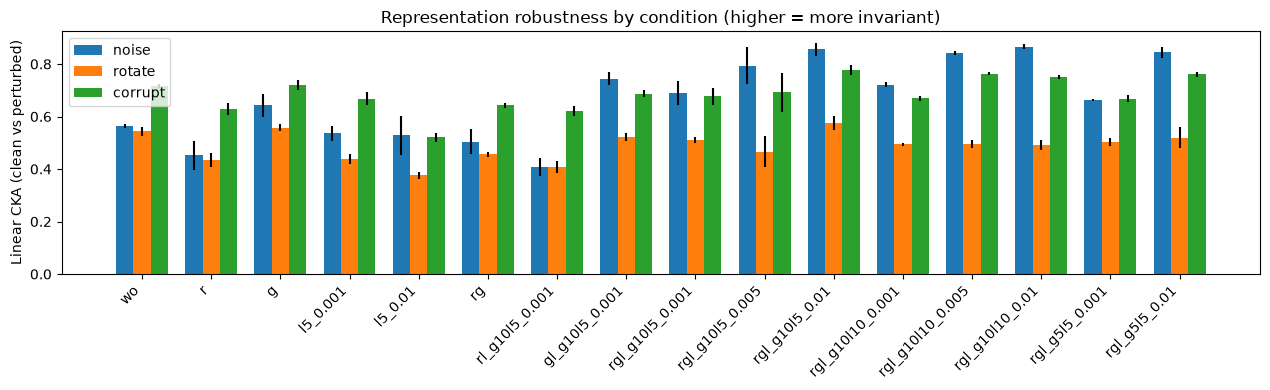

In [21]:
tags = list(robustness_results.keys())
x = np.arange(len(tags))
width = 0.25

plt.figure(figsize=(max(8, len(tags) * 0.8), 4))
for i, p in enumerate(perturbations):
    means = [np.mean(robustness_results[t][p]) for t in tags]
    stds = [np.std(robustness_results[t][p]) for t in tags]
    plt.bar(x + i * width, means, width, yerr=stds, label=p)
plt.xticks(x + width, tags, rotation=45, ha='right')
plt.ylabel("Linear CKA (clean vs perturbed)")
plt.title("Representation robustness by condition (higher = more invariant)")
plt.legend()
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig("../figures/representation_cka_robustness.svg")

#### 4c. Frozen-probe transfer accuracy (CKA collapse-트랩 방지용 지표)

CKA는 라벨을 안 보고 clean feature와 perturbed feature가 비슷한 모양이냐만 보기 때문에 애초에 정확도가 낮은 모델이면 얘 정확도도 낮아짐 
그래서 **clean feature로 학습한 linear probe를 재학습 없이 그대로 perturbed feature에 적용**해서 정확도를 보자  
표현이 뭉개졌다면 clean에서 그은 결정 경계가 corrupted feature를 못 알아볼 테니 정확도가 낮게 나옴 

- `probe_train_idx`(위 1번 probe 셀에서 이미 씀)로 probe를 새로 학습(모델별로 독립적인 probe)
- `robust_idx`/`clean_batch`/`perturbed_batches`(위 4번 CKA 셀에서 이미 계산됨)를 그대로 재사용
- `retention = perturbed_acc / clean_acc` (1에 가까울수록 clean 성능을 그대로 유지)

In [22]:
robust_labels = np.array(cifar_test_raw.targets)[robust_idx]  # clean_batch/perturbed_batches와 순서 동일

probe_transfer_results = {}
for tag in available_tags:
    clean_accs = []
    perturb_accs = {p: [] for p in perturbations}
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)

        # clean train feature로 probe 학습 (1번 probe 셀과 동일한 방식, 이 셀만의 독립 fit)
        train_feats, train_labels = extract_features(model, cifar_train, probe_train_idx)
        scaler = StandardScaler().fit(train_feats)
        clf = LogisticRegression(max_iter=2000, C=1.0)
        clf.fit(scaler.transform(train_feats), train_labels)

        clean_feats = extract_features_batch(model, clean_batch)
        clean_acc = clf.score(scaler.transform(clean_feats), robust_labels)
        clean_accs.append(clean_acc)

        for p in perturbations:
            pert_feats = extract_features_batch(model, perturbed_batches[p])
            perturb_accs[p].append(clf.score(scaler.transform(pert_feats), robust_labels))

    probe_transfer_results[tag] = dict(clean=clean_accs, **perturb_accs)
    clean_mean = np.mean(clean_accs)
    line = f"{tag:16s}: clean={clean_mean*100:.2f}  "
    line += "  ".join(
        f"{p}={np.mean(perturb_accs[p])*100:.2f}(retain={np.mean(perturb_accs[p])/clean_mean*100:.0f}%)"
        for p in perturbations
    )
    print(line)

wo              : clean=90.10  noise=36.33(retain=40%)  rotate=44.17(retain=49%)  corrupt=61.33(retain=68%)
r               : clean=90.03  noise=34.10(retain=38%)  rotate=39.80(retain=44%)  corrupt=59.57(retain=66%)
g               : clean=89.93  noise=52.80(retain=59%)  rotate=46.77(retain=52%)  corrupt=61.30(retain=68%)
l5_0.001        : clean=91.67  noise=31.27(retain=34%)  rotate=36.80(retain=40%)  corrupt=58.77(retain=64%)
l5_0.01         : clean=83.70  noise=49.20(retain=59%)  rotate=36.03(retain=43%)  corrupt=49.97(retain=60%)
rg              : clean=89.77  noise=47.90(retain=53%)  rotate=43.43(retain=48%)  corrupt=59.37(retain=66%)
rl_g10l5_0.001  : clean=89.80  noise=25.13(retain=28%)  rotate=31.83(retain=35%)  corrupt=55.90(retain=62%)
gl_g10l5_0.001  : clean=87.97  noise=60.97(retain=69%)  rotate=43.23(retain=49%)  corrupt=57.60(retain=65%)
rgl_g10l5_0.001 : clean=86.93  noise=55.17(retain=63%)  rotate=41.23(retain=47%)  corrupt=55.07(retain=63%)
rgl_g10l5_0.005 : clean=81.1


=== CKA(clean-collapse 착시 가능) vs probe-transfer retention(collapse에 안 속음) ===
wo               noise   : CKA=0.564  probe_retention=0.403
wo               rotate  : CKA=0.543  probe_retention=0.490
wo               corrupt : CKA=0.717  probe_retention=0.681
r                noise   : CKA=0.452  probe_retention=0.379
r                rotate  : CKA=0.434  probe_retention=0.442
r                corrupt : CKA=0.628  probe_retention=0.662
g                noise   : CKA=0.642  probe_retention=0.587
g                rotate  : CKA=0.558  probe_retention=0.520
g                corrupt : CKA=0.720  probe_retention=0.682
l5_0.001         noise   : CKA=0.536  probe_retention=0.341
l5_0.001         rotate  : CKA=0.439  probe_retention=0.401
l5_0.001         corrupt : CKA=0.667  probe_retention=0.641
l5_0.01          noise   : CKA=0.528  probe_retention=0.588
l5_0.01          rotate  : CKA=0.377  probe_retention=0.431
l5_0.01          corrupt : CKA=0.521  probe_retention=0.597
rg               nois

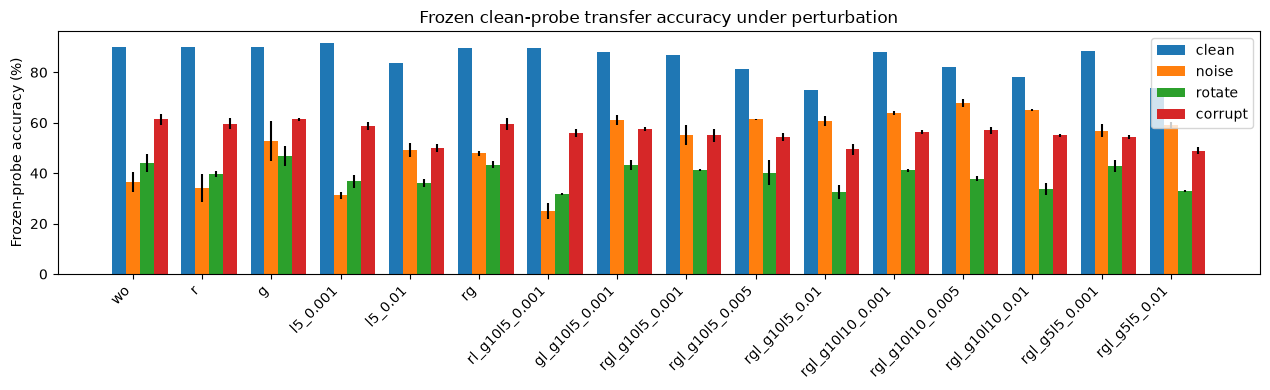

In [32]:
tags = list(probe_transfer_results.keys())
x = np.arange(len(tags))
width = 0.2
dot_offsets = [-0.05, 0.0, 0.05]  # 그룹 폭(width=0.2) 안에서 net 3개 점을 살짝 벌려서 표시

factor_alpha = [0.4 + 0.2 * len(parse_tag_style(t)[0]) for t in tags]  # factor(mechanism) 개수가 많을수록 진하게(불투명)
series = [("clean", x - width, "tab:gray")] + [
    (p, x + i * width, c) for i, (p, c) in enumerate(zip(perturbations, ["tab:orange", "tab:green", "tab:red"]))
]

plt.figure(figsize=(max(8, len(tags) * 0.8), 4))
for name, xpos, color in series:
    means = [np.mean(probe_transfer_results[t][name]) * 100 for t in tags]
    bar_colors = [mcolors.to_rgba(color, alpha=a) for a in factor_alpha]  # matplotlib bar()는 alpha에 리스트를 못 받아서 색에 직접 섞음
    plt.bar(xpos, means, width, color=bar_colors, label=name, zorder=2)
    for xi, t in enumerate(tags):
        accs = np.array(probe_transfer_results[t][name]) * 100
        for off, acc in zip(dot_offsets, accs):
            plt.scatter(xpos[xi] + off, acc, color="black", s=10, zorder=3)
    for xi, m in enumerate(means):
        plt.text(xpos[xi], m + 1, f"{m:.0f}", ha="center", fontsize=6)

plt.xticks(x, tags, rotation=45, ha='right')
plt.ylabel("Frozen-probe accuracy (%)")
plt.title("Frozen clean-probe transfer accuracy under perturbation")
plt.legend()
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig("../figures/representation_probe_transfer_robustness.svg")

# CKA vs probe-transfer retention 나란히 비교 -- collapse 조건일수록 둘이 반대로 움직일 것
print()
print("=== CKA(clean-collapse 착시 가능) vs probe-transfer retention(collapse에 안 속음) ===")
for tag in tags:
    clean_mean = np.mean(probe_transfer_results[tag]["clean"])
    for p in perturbations:
        cka_val = np.mean(robustness_results[tag][p])
        retain = np.mean(probe_transfer_results[tag][p]) / clean_mean
        print(f"{tag:16s} {p:8s}: CKA={cka_val:.3f}  probe_retention={retain:.3f}")

In [ ]:
# 4c-filtered. alpha=0.001인 것만 (+ alpha 없는 wo/r/g/rg) -- ch_plot에서 쓴 것과 같은 필터
tags = [t for t in probe_transfer_results if not (t.endswith("_0.01") or t.endswith("_0.005"))]
x = np.arange(len(tags))
width = 0.2
dot_offsets = [-0.05, 0.0, 0.05]  # 그룹 폭(width=0.2) 안에서 net 3개 점을 살짝 벌려서 표시

factor_alpha = [0.4 + 0.2 * len(parse_tag_style(t)[0]) for t in tags]  # factor(mechanism) 개수가 많을수록 진하게(불투명)
series = [("clean", x - width, "tab:gray")] + [
    (p, x + i * width, c) for i, (p, c) in enumerate(zip(perturbations, ["tab:orange", "tab:green", "tab:red"]))
]

plt.figure(figsize=(max(8, len(tags) * 0.8), 4))
for name, xpos, color in series:
    means = [np.mean(probe_transfer_results[t][name]) * 100 for t in tags]
    bar_colors = [mcolors.to_rgba(color, alpha=a) for a in factor_alpha]  # matplotlib bar()는 alpha에 리스트를 못 받아서 색에 직접 섞음
    plt.bar(xpos, means, width, color=bar_colors, label=name, zorder=2)
    for xi, t in enumerate(tags):
        accs = np.array(probe_transfer_results[t][name]) * 100
        for off, acc in zip(dot_offsets, accs):
            plt.scatter(xpos[xi] + off, acc, color="black", s=10, zorder=3)
    for xi, m in enumerate(means):
        plt.text(xpos[xi], m + 1, f"{m:.0f}", ha="center", fontsize=6)

plt.xticks(x, tags, rotation=45, ha='right')
plt.ylabel("Frozen-probe accuracy (%)")
plt.title("Frozen clean-probe transfer accuracy under perturbation (alpha=0.001, scheduling variants)")
plt.legend()
plt.tight_layout()
plt.show()

#### 4d. Participation Ratio 변화 (ΔPR) -- 붕괴(collapse)를 직접 재는 지표

CKA는 "clean과 perturbed 표현이 서로 비슷한가"만 보고, 표현이 소수 차원으로 뭉개져도(collapse) 결과적으로 비슷해 보이면 "안 흔들린다"고 착시를 일으킬 수 있음(`rgl_g10l5_0.01`에서 이미 확인함).

**Participation Ratio**는 그 붕괴 자체를 직접 재는 표준 지표:

```
PR = (sum(λ))^2 / sum(λ^2)      (λ = feature 공분산 고유값)
```

분산이 여러 차원에 고르게 퍼져 있으면 PR이 크고(=고차원적), 소수 차원에 몰리면 PR이 작음(=붕괴). `retain = PR_perturbed / PR_clean`이 1에 가까울수록 corruption이 와도 차원 구조가 안 무너진다는 뜻.

In [ ]:
def compute_pr(feats):
    """Participation Ratio: eigenspectrum 기반 effective dimensionality. PR = (sum(λ))^2 / sum(λ^2)."""
    feats = feats - feats.mean(axis=0, keepdims=True)
    s = np.linalg.svd(feats, compute_uv=False)
    eigvals = (s ** 2) / (feats.shape[0] - 1)
    return (eigvals.sum() ** 2) / (eigvals ** 2).sum()


pr_results = {}
for tag in available_tags:
    pr_clean_list = []
    pr_perturb_list = {p: [] for p in perturbations}
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        clean_feats = extract_features_batch(model, clean_batch)
        pr_clean_list.append(compute_pr(clean_feats))
        for p in perturbations:
            pert_feats = extract_features_batch(model, perturbed_batches[p])
            pr_perturb_list[p].append(compute_pr(pert_feats))

    pr_results[tag] = dict(clean=pr_clean_list, **pr_perturb_list)
    clean_mean = np.mean(pr_clean_list)
    line = f"{tag:16s}: PR_clean={clean_mean:.2f}  "
    line += "  ".join(
        f"{p}:PR={np.mean(pr_perturb_list[p]):.2f}(retain={np.mean(pr_perturb_list[p]) / clean_mean * 100:.0f}%)"
        for p in perturbations
    )
    print(line)

In [ ]:
tags = list(pr_results.keys())
x = np.arange(len(tags))
width = 0.2

plt.figure(figsize=(max(8, len(tags) * 0.8), 4))
plt.bar(x - width, [np.mean(pr_results[t]["clean"]) for t in tags], width, label="clean")
for i, p in enumerate(perturbations):
    means = [np.mean(pr_results[t][p]) for t in tags]
    stds = [np.std(pr_results[t][p]) for t in tags]
    plt.bar(x + i * width, means, width, yerr=stds, label=p)
plt.xticks(x, tags, rotation=45, ha="right")
plt.ylabel("Participation Ratio")
plt.title("Participation Ratio (effective dimensionality) under perturbation")
plt.legend()
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig("../figures/representation_participation_ratio.svg")
plt.show()

# CKA / probe-retention / PR-retention 3가지를 한 번에 비교 -- collapse된 조건은 CKA만 높고
# probe-retention과 PR-retention은 낮게 나와야 함
print("\n=== CKA vs probe-retention vs PR-retention (collapse된 조건은 이 셋 사이 엇갈려야 정상) ===")
for tag in tags:
    clean_probe = np.mean(probe_transfer_results[tag]["clean"])
    clean_pr = np.mean(pr_results[tag]["clean"])
    for p in perturbations:
        cka_val = np.mean(robustness_results[tag][p])
        probe_retain = np.mean(probe_transfer_results[tag][p]) / clean_probe
        pr_retain = np.mean(pr_results[tag][p]) / clean_pr
        print(f"{tag:16s} {p:8s}: CKA={cka_val:.3f}  probe_retain={probe_retain:.3f}  PR_retain={pr_retain:.3f}")

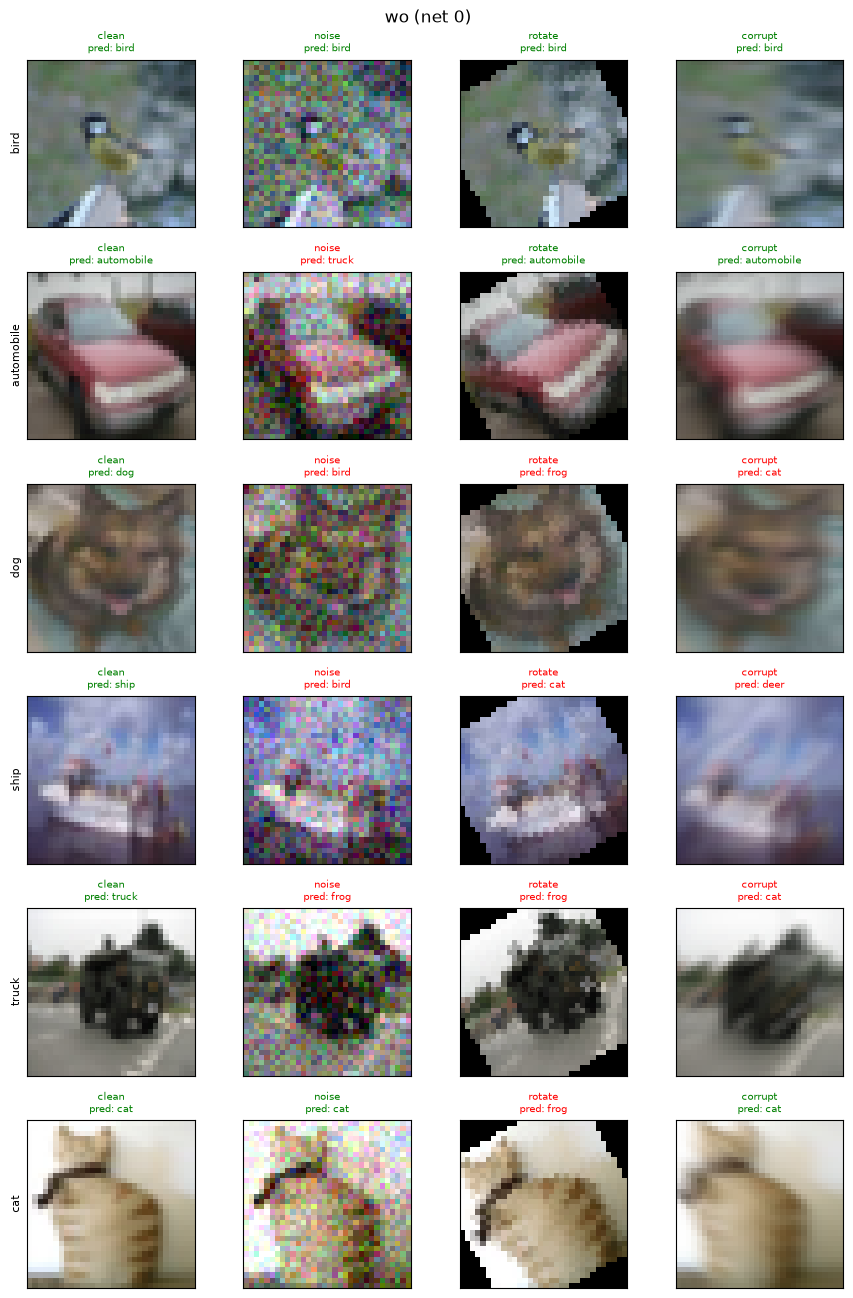

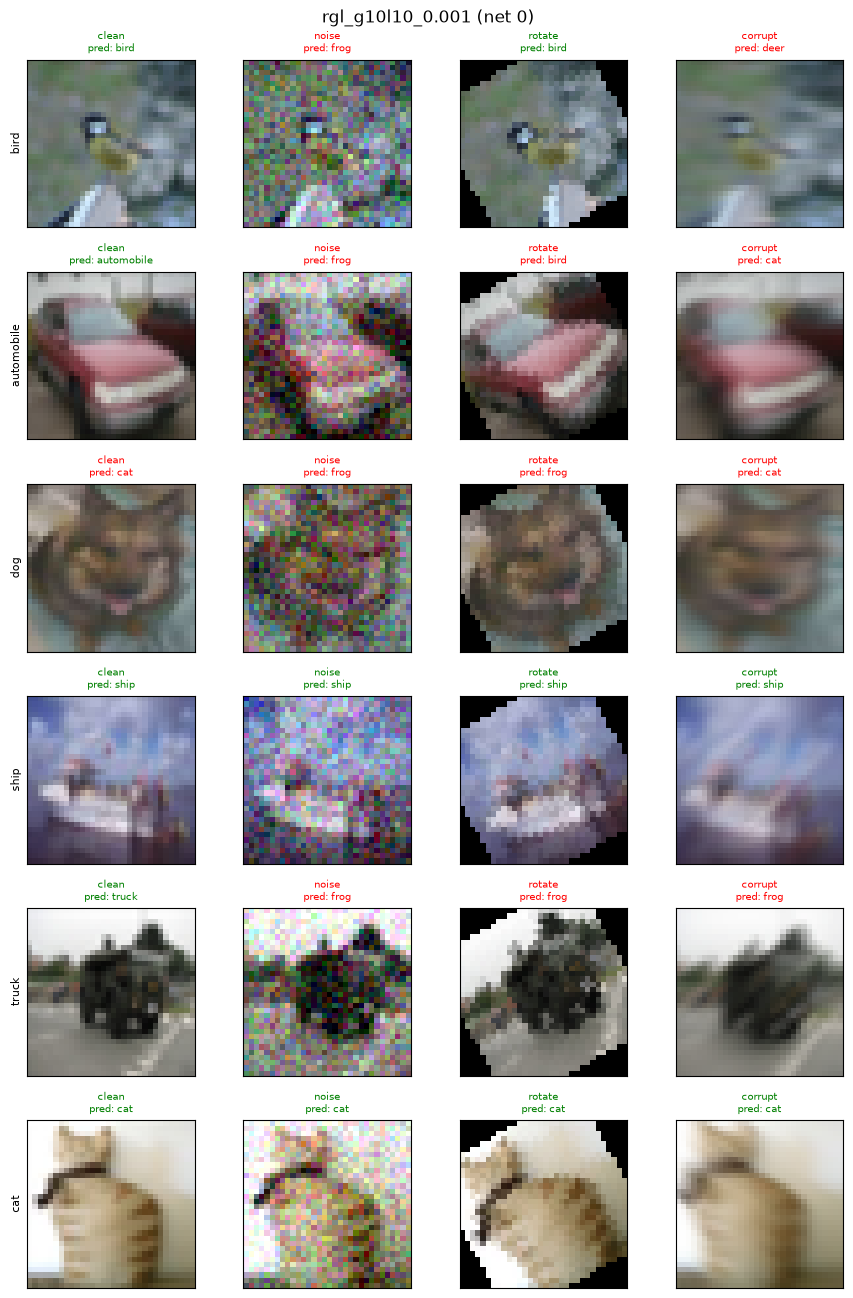

In [34]:
# CKA가 아니라 실제 예측이 perturbation에 어떻게 반응하는지 이미지로 확인
class_names = cifar_test_raw.classes


def unnormalize(x):
    mean = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
    std = torch.tensor(CIFAR_STD).view(3, 1, 1)
    return (x.cpu() * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()


def show_perturbation_predictions(tag, net_idx=0, num_examples=6, seed=42):
    model = load_model(tag, net_idx)
    idx = np.random.RandomState(seed).choice(len(cifar_test_raw), num_examples, replace=False)
    perturb_types = ["clean", "noise", "rotate", "corrupt"]

    fig, axes = plt.subplots(num_examples, 4, figsize=(9, 2.2 * num_examples))
    for row, i in enumerate(idx):
        true_name = class_names[cifar_test_raw.targets[i]]
        for col, p in enumerate(perturb_types):
            x = build_batch([i], p)[0]
            with torch.no_grad():
                pred_name = class_names[model(x.unsqueeze(0)).argmax(1).item()]
            correct = pred_name == true_name
            ax = axes[row, col]
            ax.imshow(unnormalize(x))
            ax.set_xticks([]); ax.set_yticks([])
            if col == 0:
                ax.set_ylabel(true_name, fontsize=8)
            ax.set_title(f"{p}\npred: {pred_name}", fontsize=7, color="green" if correct else "red")
    plt.suptitle(f"{tag} (net {net_idx})")
    plt.tight_layout()
    if SAVE_FIGURES:
        plt.savefig(f"../figures/representation_perturbation_examples_{tag}.svg")

show_perturbation_predictions("wo", 0)
show_perturbation_predictions("rgl_g10l10_0.001", 0)

4b. 안 본 corruption으로의 전이 (unseen corruption generalization)

위 CKA robustness는 corruption 한 종류(motion_blur)만 봤음. 여기서는 Hendrycks CIFAR-10-C 표준
15종 corruption(noise/blur/weather/digital, 4개 카테고리)을 전부 쓰되, 한 카테고리 전체
(`weather`: snow/frost/fog/brightness)를 통째로 held-out으로 빼서 계산에서 완전히 제외.

"corruption-general robustness"가 실제로 일반적인 성질이라면, 본 카테고리(noise/blur/digital, 11종)에서
계산한 평균 CKA robustness가 안 본 카테고리(`weather`, 4종)의 평균 CKA robustness와도 조건들 사이에서
같은 순위로 나타나야 함 -- 즉 두 값이 조건 간 상관관계를 보여야 "전이"된다고 말할 수 있음. 이 파이프라인은
지금 쓰고 있는 것과 같은 구현(`robust_idx`, `clean_batch`, `extract_features_batch`, `linear_cka`)을
그대로 재사용하고, corruption 목록만 나눠서 재실행.

In [25]:
CORRUPTION_CATEGORIES = {
    "noise":   ["gaussian_noise", "shot_noise", "impulse_noise"],
    "blur":    ["defocus_blur", "glass_blur", "motion_blur", "zoom_blur"],
    "weather": ["snow", "frost", "fog", "brightness"],
    "digital": ["contrast", "elastic_transform", "pixelate", "jpeg_compression"],
}
HELD_OUT_CATEGORY = "weather"

seen_corruptions = [c for cat, names in CORRUPTION_CATEGORIES.items() if cat != HELD_OUT_CATEGORY for c in names]
heldout_corruptions = CORRUPTION_CATEGORIES[HELD_OUT_CATEGORY]
all_corruptions = seen_corruptions + heldout_corruptions
print(f"seen ({len(seen_corruptions)}): {seen_corruptions}")
print(f"held-out ({len(heldout_corruptions)}, category={HELD_OUT_CATEGORY}): {heldout_corruptions}")

_corruption_cache = {}


def load_corruption_severity5(name):
    if name not in _corruption_cache:
        _corruption_cache[name] = np.load(os.path.join(cifar10c_root, f"{name}.npy"))[40000:50000]
    return _corruption_cache[name]


def build_corrupt_batch(indices, corruption_name):
    arr = load_corruption_severity5(corruption_name)
    imgs = [Image.fromarray(arr[i]) for i in indices]
    xs = [_normalize(TF.to_tensor(img)) for img in imgs]
    return torch.stack(xs).to(device)


# robust_idx/clean_batch는 위 4. CKA 셀에서 이미 계산됨 -- 같은 1000장 재사용
corrupt_batches = {c: build_corrupt_batch(robust_idx, c) for c in all_corruptions}

cka_raw = {tag: {c: [] for c in all_corruptions} for tag in available_tags}
for tag in available_tags:
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        clean_feats = extract_features_batch(model, clean_batch)
        for c in all_corruptions:
            pert_feats = extract_features_batch(model, corrupt_batches[c])
            cka_raw[tag][c].append(linear_cka(clean_feats, pert_feats))
    seen_avg = np.mean([np.mean(cka_raw[tag][c]) for c in seen_corruptions])
    heldout_avg = np.mean([np.mean(cka_raw[tag][c]) for c in heldout_corruptions])
    print(f"{tag:16s}: seen_avg={seen_avg:.3f}  heldout_avg={heldout_avg:.3f}")

seen (11): ['gaussian_noise', 'shot_noise', 'impulse_noise', 'defocus_blur', 'glass_blur', 'motion_blur', 'zoom_blur', 'contrast', 'elastic_transform', 'pixelate', 'jpeg_compression']
held-out (4, category=weather): ['snow', 'frost', 'fog', 'brightness']
wo              : seen_avg=0.661  heldout_avg=0.760
r               : seen_avg=0.579  heldout_avg=0.691
g               : seen_avg=0.700  heldout_avg=0.765
l5_0.001        : seen_avg=0.613  heldout_avg=0.751
l5_0.01         : seen_avg=0.568  heldout_avg=0.621
rg              : seen_avg=0.607  heldout_avg=0.707
rl_g10l5_0.001  : seen_avg=0.541  heldout_avg=0.695
gl_g10l5_0.001  : seen_avg=0.715  heldout_avg=0.773
rgl_g10l5_0.001 : seen_avg=0.689  heldout_avg=0.765
rgl_g10l5_0.005 : seen_avg=0.736  heldout_avg=0.780
rgl_g10l5_0.01  : seen_avg=0.816  heldout_avg=0.831
rgl_g10l10_0.001: seen_avg=0.706  heldout_avg=0.761
rgl_g10l10_0.005: seen_avg=0.798  heldout_avg=0.818
rgl_g10l10_0.01 : seen_avg=0.807  heldout_avg=0.817
rgl_g5l5_0.001  :

Spearman rho=0.956 (p=7.76e-09)   Pearson r=0.924 (p=3.12e-07)


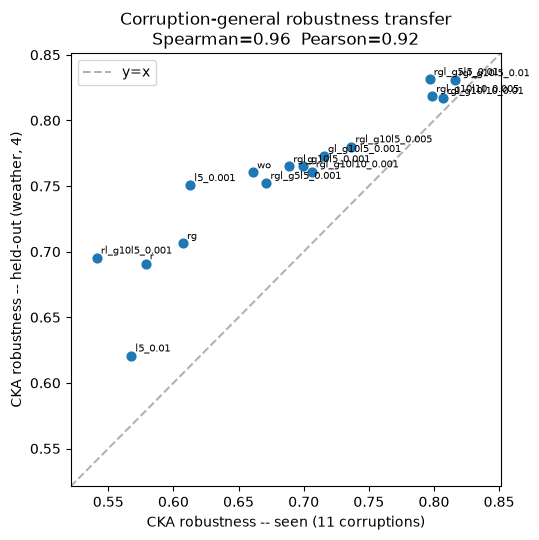

In [26]:
from scipy.stats import spearmanr, pearsonr

seen_score = {tag: np.mean([np.mean(cka_raw[tag][c]) for c in seen_corruptions]) for tag in available_tags}
heldout_score = {tag: np.mean([np.mean(cka_raw[tag][c]) for c in heldout_corruptions]) for tag in available_tags}

tags_corr = list(available_tags)
seen_vals = [seen_score[t] for t in tags_corr]
heldout_vals = [heldout_score[t] for t in tags_corr]

rho, p_rho = spearmanr(seen_vals, heldout_vals)
r, p_r = pearsonr(seen_vals, heldout_vals)
print(f"Spearman rho={rho:.3f} (p={p_rho:.3g})   Pearson r={r:.3f} (p={p_r:.3g})")

plt.figure(figsize=(5.5, 5.5))
plt.scatter(seen_vals, heldout_vals, s=40)
for t, x, y in zip(tags_corr, seen_vals, heldout_vals):
    plt.annotate(t, (x, y), fontsize=7, xytext=(3, 3), textcoords='offset points')
lo = min(seen_vals + heldout_vals) - 0.02
hi = max(seen_vals + heldout_vals) + 0.02
plt.plot([lo, hi], [lo, hi], 'k--', alpha=0.3, label='y=x')
plt.xlim(lo, hi); plt.ylim(lo, hi)
plt.xlabel(f"CKA robustness -- seen ({len(seen_corruptions)} corruptions)")
plt.ylabel(f"CKA robustness -- held-out ({HELD_OUT_CATEGORY}, {len(heldout_corruptions)})")
plt.title(f"Corruption-general robustness transfer\nSpearman={rho:.2f}  Pearson={r:.2f}")
plt.legend()
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig("../figures/representation_corruption_transfer.svg")

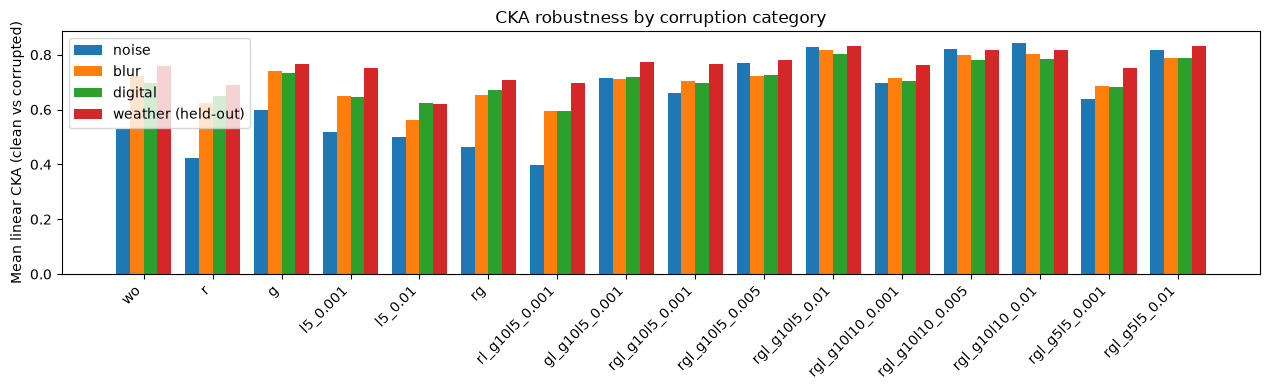

In [27]:
tags_bar = list(available_tags)
x = np.arange(len(tags_bar))
width = 0.2
cats_order = ["noise", "blur", "digital", "weather"]  # weather = held-out, 마지막에 표시

plt.figure(figsize=(max(8, len(tags_bar) * 0.8), 4))
for i, cat in enumerate(cats_order):
    names = CORRUPTION_CATEGORIES[cat]
    means = [np.mean([np.mean(cka_raw[t][c]) for c in names]) for t in tags_bar]
    label = f"{cat} (held-out)" if cat == HELD_OUT_CATEGORY else cat
    plt.bar(x + i * width, means, width, label=label)
plt.xticks(x + width * 1.5, tags_bar, rotation=45, ha='right')
plt.ylabel("Mean linear CKA (clean vs corrupted)")
plt.title("CKA robustness by corruption category")
plt.legend()
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig("../figures/representation_corruption_category_breakdown.svg")

5. Adversarial robustness (FGSM / PGD)

CIFAR-10 clean test set 기준, L∞ threat model 표준 설정(eps=8/255, PGD alpha=2/255, steps=10, random start -- Madry et al. 컨벤션) 사용.

- **FGSM** -- 1-step, 빠르지만 약한 공격 (gradient masking에 취약해서 강건성을 과대평가할 수 있음)
- **PGD** -- multi-step, random start 포함, 더 신뢰할 수 있는 강건성 하한선

공격은 정규화 이전 [0,1] 픽셀 공간에서 수행 -- `NormalizedModel`로 감싸서 정규화를 forward 안으로 넣어야 eps가 실제 픽셀 스케일(8/255)을 그대로 가짐. 계산량 때문에 PCA/manifold와 같은 방식으로 **net 0 대표 + test set subsample**로 평가.

In [28]:
import torch.nn as nn
import torch.nn.functional as F

EPS = 8 / 255
PGD_ALPHA = 2 / 255
PGD_STEPS = 10
ADV_SAMPLE_SIZE = 1000  # 전체 test set(10000) x 12조건 x PGD-10은 너무 느림 -- PCA/manifold와 동일하게 subsample


class NormalizedModel(nn.Module):
    """공격은 [0,1] 픽셀 공간에서 하고, 정규화는 forward 안에서 해서 eps가 실제 픽셀 스케일을 갖게 함."""
    def __init__(self, model, mean, std):
        super().__init__()
        self.model = model
        self.register_buffer("mean", torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer("std", torch.tensor(std).view(1, 3, 1, 1))

    def forward(self, x):
        return self.model((x - self.mean) / self.std)


cifar_test_raw01 = torchvision.datasets.CIFAR10(
    root=dataset_dir, train=False, download=True, transform=T.ToTensor(),  # [0,1], 정규화 안 함
)
rng = np.random.RandomState(4)
adv_idx = rng.choice(len(cifar_test_raw01), ADV_SAMPLE_SIZE, replace=False)
adv_loader = DataLoader(Subset(cifar_test_raw01, adv_idx), batch_size=128, shuffle=False, num_workers=0)


def fgsm_attack(model, x, y, eps=EPS):
    x_adv = x.clone().detach().requires_grad_(True)
    loss = F.cross_entropy(model(x_adv), y)
    grad = torch.autograd.grad(loss, x_adv)[0]
    return (x_adv + eps * grad.sign()).clamp(0, 1).detach()


def pgd_attack(model, x, y, eps=EPS, alpha=PGD_ALPHA, steps=PGD_STEPS):
    x_orig = x.clone().detach()
    x_adv = (x_orig + torch.empty_like(x_orig).uniform_(-eps, eps)).clamp(0, 1).detach()
    for _ in range(steps):
        x_adv.requires_grad_(True)
        loss = F.cross_entropy(model(x_adv), y)
        grad = torch.autograd.grad(loss, x_adv)[0]
        x_adv = x_adv.detach() + alpha * grad.sign()
        x_adv = torch.min(torch.max(x_adv, x_orig - eps), x_orig + eps).clamp(0, 1).detach()
    return x_adv


def evaluate_adversarial(model, loader):
    wrapped = NormalizedModel(model, CIFAR_MEAN, CIFAR_STD).to(device)  # CIFAR_MEAN/STD는 위 CKA 셀에서 이미 정의됨
    wrapped.eval()
    clean_correct = fgsm_correct = pgd_correct = total = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        with torch.no_grad():
            clean_correct += (wrapped(x).argmax(1) == y).sum().item()

        x_fgsm = fgsm_attack(wrapped, x, y)
        with torch.no_grad():
            fgsm_correct += (wrapped(x_fgsm).argmax(1) == y).sum().item()

        x_pgd = pgd_attack(wrapped, x, y)
        with torch.no_grad():
            pgd_correct += (wrapped(x_pgd).argmax(1) == y).sum().item()

        total += y.size(0)
    return clean_correct / total, fgsm_correct / total, pgd_correct / total

In [29]:
adv_results = {}
for tag in available_tags:
    clean_accs, fgsm_accs, pgd_accs = [], [], []
    for net_idx in range(num_net):
        model = load_model(tag, net_idx)
        clean_acc, fgsm_acc, pgd_acc = evaluate_adversarial(model, adv_loader)
        clean_accs.append(clean_acc)
        fgsm_accs.append(fgsm_acc)
        pgd_accs.append(pgd_acc)
    adv_results[tag] = dict(
        clean_mean=np.mean(clean_accs), clean_std=np.std(clean_accs),
        fgsm_mean=np.mean(fgsm_accs), fgsm_std=np.std(fgsm_accs),
        pgd_mean=np.mean(pgd_accs), pgd_std=np.std(pgd_accs),
    )
    print(f"{tag:16s}: clean={np.mean(clean_accs)*100:.2f}±{np.std(clean_accs)*100:.2f}  "
          f"FGSM={np.mean(fgsm_accs)*100:.2f}±{np.std(fgsm_accs)*100:.2f}  "
          f"PGD-{PGD_STEPS}={np.mean(pgd_accs)*100:.2f}±{np.std(pgd_accs)*100:.2f}")

wo              : clean=89.87±0.26  FGSM=7.70±0.83  PGD-10=0.03±0.05
r               : clean=89.73±0.57  FGSM=14.80±1.47  PGD-10=0.30±0.08
g               : clean=90.47±0.92  FGSM=9.10±0.29  PGD-10=0.00±0.00
l5_0.001        : clean=92.13±0.62  FGSM=9.87±0.62  PGD-10=0.00±0.00
l5_0.01         : clean=85.87±0.78  FGSM=10.23±1.22  PGD-10=0.03±0.05
rg              : clean=90.17±0.69  FGSM=13.23±1.41  PGD-10=0.30±0.08
rl_g10l5_0.001  : clean=89.90±0.16  FGSM=11.83±2.46  PGD-10=0.30±0.42
gl_g10l5_0.001  : clean=89.90±0.16  FGSM=13.57±1.46  PGD-10=0.00±0.00
rgl_g10l5_0.001 : clean=88.43±0.69  FGSM=11.27±0.82  PGD-10=0.83±0.47
rgl_g10l5_0.005 : clean=85.03±1.78  FGSM=9.00±2.14  PGD-10=0.00±0.00
rgl_g10l5_0.01  : clean=80.53±0.62  FGSM=6.50±0.29  PGD-10=0.00±0.00
rgl_g10l10_0.001: clean=88.90±0.22  FGSM=14.93±1.88  PGD-10=0.43±0.33
rgl_g10l10_0.005: clean=85.70±0.75  FGSM=10.60±0.50  PGD-10=0.47±0.21
rgl_g10l10_0.01 : clean=83.77±0.81  FGSM=9.37±1.23  PGD-10=0.07±0.09
rgl_g5l5_0.001  : clean=88

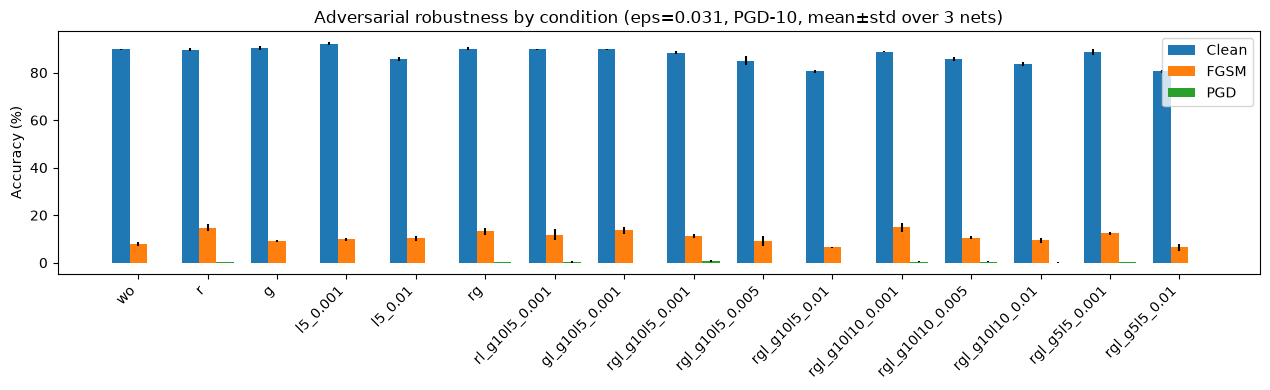

In [30]:
tags = list(adv_results.keys())
conditions_plot = ["clean", "fgsm", "pgd"]
x = np.arange(len(tags))
width = 0.25

plt.figure(figsize=(max(8, len(tags) * 0.8), 4))
for i, cond in enumerate(conditions_plot):
    vals = [adv_results[t][f"{cond}_mean"] * 100 for t in tags]
    errs = [adv_results[t][f"{cond}_std"] * 100 for t in tags]
    plt.bar(x + i * width, vals, width, yerr=errs, label=cond.upper() if cond != "clean" else "Clean")
plt.xticks(x + width, tags, rotation=45, ha='right')
plt.ylabel("Accuracy (%)")
plt.title(f"Adversarial robustness by condition (eps={EPS:.3f}, PGD-{PGD_STEPS}, mean±std over 3 nets)")
plt.legend()
plt.tight_layout()
if SAVE_FIGURES:
    plt.savefig("../figures/representation_adversarial_robustness.svg")

## 6. Epoch별 representation 변화 (t-SNE)

학습 중간중간 저장해둔 `snapshot_{tag}_{net}_epoch{N}.pth`(10 epoch 간격)을 불러와서, 그 시점의
penultimate feature를 t-SNE로 2D에 투영. 클래스는 두 그룹으로 묶어서 색칠:

- **vehicle**(airplane/automobile/ship/truck) = 파란 계열
- **animal**(bird/cat/deer/dog/frog/horse) = 빨간 계열

가소성이 닫히기 전/후로 클래스 간 분리가 어떻게 형성되고 굳어지는지(혹은 안 굳는지)를 눈으로 봄.
`show_tsne_over_epochs(tag, net_idx)`를 원하는 조건에 대해 호출하면 됨 -- 계산량 때문에(t-SNE를
epoch마다 새로 돌림) 기본으로는 전체 조건을 자동으로 돌리지 않음.

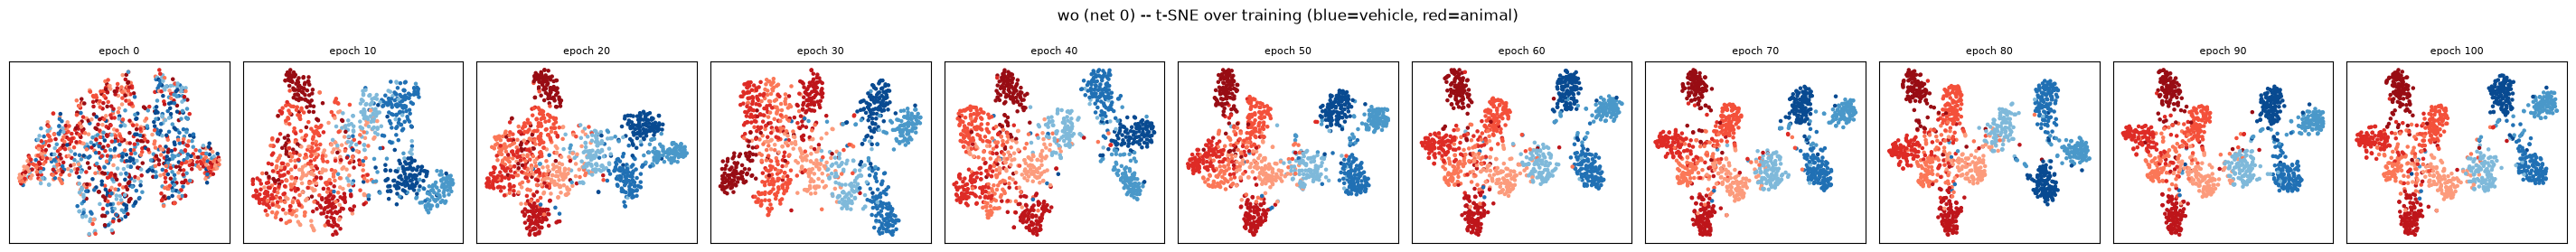

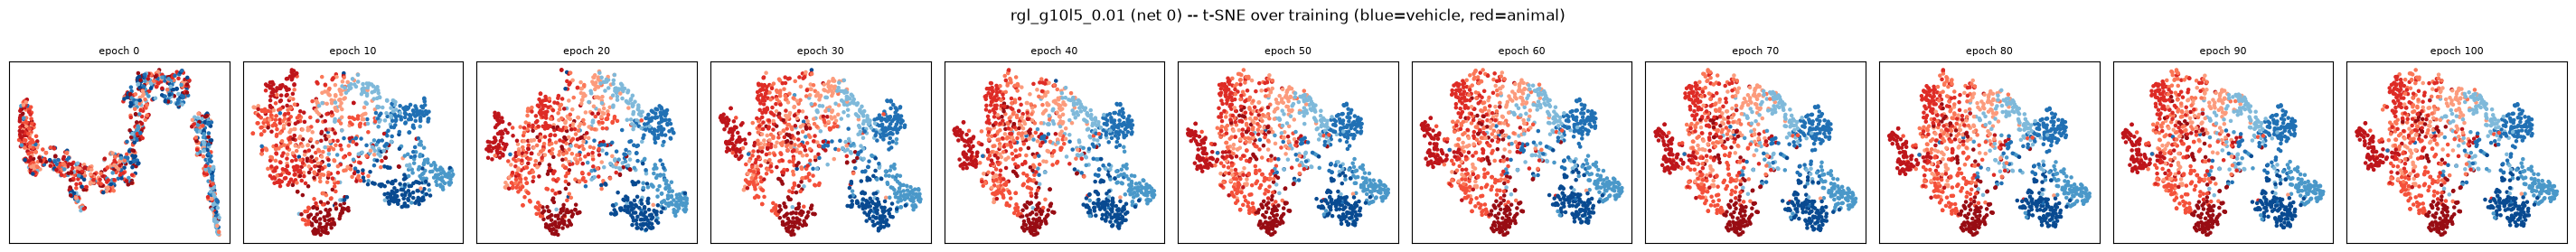

In [ ]:
from sklearn.manifold import TSNE

VEHICLE_IDX = [0, 1, 8, 9]        # airplane, automobile, ship, truck
ANIMAL_IDX  = [2, 3, 4, 5, 6, 7]  # bird, cat, deer, dog, frog, horse

vehicle_shades = plt.cm.Blues(np.linspace(0.45, 0.9, len(VEHICLE_IDX)))
animal_shades = plt.cm.Reds(np.linspace(0.35, 0.9, len(ANIMAL_IDX)))

tsne_class_colors = [None] * 10
for idx, c in zip(VEHICLE_IDX, vehicle_shades):
    tsne_class_colors[idx] = c
for idx, c in zip(ANIMAL_IDX, animal_shades):
    tsne_class_colors[idx] = c

tsne_idx = np.random.RandomState(5).choice(len(cifar_test), 1000, replace=False)  # t-SNE용 고정 subset


def available_snapshot_epochs(tag, net_idx):
    return [e for e in range(0, 101, 10)
            if os.path.exists(os.path.join(save_dir, f"snapshot_{tag}_{net_idx}_epoch{e}.pth"))]


def load_snapshot_model(tag, net_idx, epoch):
    model = resnet18().to(device)
    path = os.path.join(save_dir, f"snapshot_{tag}_{net_idx}_epoch{epoch}.pth")
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    return model


def show_tsne_over_epochs(tag, net_idx=0, seed=0):
    """학습 과정(epoch 스냅샷) 동안 t-SNE가 어떻게 변하는지 한 줄로 나란히 보여줌."""
    epochs_avail = available_snapshot_epochs(tag, net_idx)
    if not epochs_avail:
        print(f"{tag} net{net_idx}: no snapshots found")
        return

    fig, axes = plt.subplots(1, len(epochs_avail), figsize=(2.6 * len(epochs_avail), 2.8))
    axes = np.atleast_1d(axes)
    for ax, epoch in zip(axes, epochs_avail):
        model = load_snapshot_model(tag, net_idx, epoch)
        feats, labels = extract_features(model, cifar_test, tsne_idx)
        proj = TSNE(n_components=2, random_state=seed, init="pca").fit_transform(feats)
        colors = [tsne_class_colors[l] for l in labels]
        ax.scatter(proj[:, 0], proj[:, 1], c=colors, s=5)
        ax.set_title(f"epoch {epoch}", fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])
    plt.suptitle(f"{tag} (net {net_idx}) - t-SNE over training")
    plt.tight_layout()
    if SAVE_FIGURES:
        plt.savefig(f"../figures/representation_tsne_epochs_{tag}_{net_idx}.svg")
    plt.show()


# 예시: baseline vs 붕괴된 조건
show_tsne_over_epochs("rgl_g10l10_0.005", 0)